#   خواندن دیتای قیمت مسکن (خانه )


In [3]:
import pandas as pd
import os

HOUSING_PATH=("E:\\jupyter\\mohamadi_video\\")

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing=load_housing_data(HOUSING_PATH)

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [18]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB


# اطلاعات فیلد خاص category
# شامل تعداد خانه های نزدیک به اقیانوس ، یک ساعت فاصله تا اقیانوس  ،...

In [20]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [21]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# هیستوگرام هر فیلد و تعداد آن فیلد 

In [22]:
import matplotlib.pyplot as plt

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

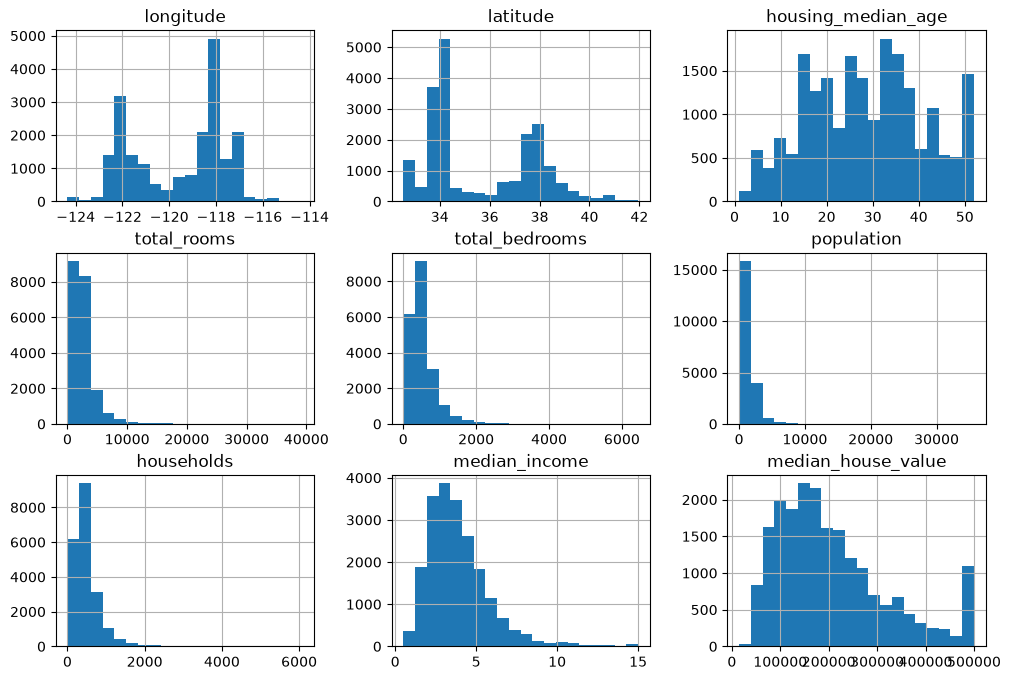

In [27]:
housing.hist(bins=20,figsize=(12,8))

# تقسیم دیتا به آموزش و تست بدون استفاده از کتابخانه های ماشین لرنیگ 
# بور زدن دیتا و بدستآوردن شماره های رندوم 
# سپس با استفاده از آن شماره های رندوم به سراغ شماره رکورد رندوم مورد نظر میرویم 
# بدین صورت رکوردهای کاملا تصادفی برای آموزش و تست بدست میآید 

In [28]:
import numpy as np
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [32]:
data=housing
test_ratio=0.2

In [33]:
test_set_size = int(len(data) * test_ratio)

In [34]:
test_set_size 

4128

In [35]:
len(data)

20640

In [46]:
 shuffled_indices = np.random.permutation(len(data))

In [47]:
shuffled_indices

array([ 9573,  7942,  6870, ...,  6928, 16055,  8686],
      shape=(20640,), dtype=int32)

In [58]:
test_indices = shuffled_indices[:test_set_size]

In [59]:
(test_indices)

array([ 9573,  7942,  6870, ...,  8935, 19104,  7364],
      shape=(4128,), dtype=int32)

In [60]:
train_indices = shuffled_indices[test_set_size:]

In [62]:
(train_indices)

array([14657, 10805, 14978, ...,  6928, 16055,  8686],
      shape=(16512,), dtype=int32)

In [55]:
16512+4128

20640

# رفتن بر روی رکوردی که شماره اش را میدهیم 

In [61]:
data.iloc[train_indices]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14657,-120.97,37.73,19,3725,543.0,1412,463,5.7476,248600,INLAND
10805,-122.04,37.62,35,899,179.0,455,185,4.2857,190400,NEAR BAY
14978,-118.01,33.95,36,1579,290.0,816,276,4.4318,181100,<1H OCEAN
3441,-118.31,33.96,48,2015,356.0,1020,338,4.0625,138700,<1H OCEAN
14755,-120.65,38.28,21,3095,681.0,1341,546,2.1382,104000,INLAND
...,...,...,...,...,...,...,...,...,...,...
4752,-118.49,34.13,24,4394,NaN,1443,528,11.2979,500001,<1H OCEAN
13168,-118.10,33.88,18,8046,1221.0,4276,1228,6.5515,319600,<1H OCEAN
6928,-122.02,37.97,36,2342,436.0,1191,416,4.0000,171000,NEAR BAY
16055,-118.26,34.06,15,326,123.0,490,105,1.4886,175000,<1H OCEAN


In [63]:
data.iloc[test_indices]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9573,-117.92,34.05,36,2241,419.0,1743,448,4.6587,161900,<1H OCEAN
7942,-117.91,33.85,22,1178,289.0,865,294,3.0250,180000,<1H OCEAN
6870,-122.05,37.33,17,3674,824.0,1364,694,6.3131,436400,<1H OCEAN
19087,-116.18,33.67,25,2888,654.0,2940,660,2.2141,66700,INLAND
14541,-121.27,37.79,16,1853,390.0,1013,362,2.7083,173900,INLAND
...,...,...,...,...,...,...,...,...,...,...
8917,-118.25,33.79,34,1349,371.0,1716,380,2.7143,138100,NEAR OCEAN
3635,-120.73,39.63,17,1791,356.0,432,190,3.8826,92400,INLAND
8935,-118.55,34.04,41,1482,239.0,617,242,8.8619,500001,<1H OCEAN
19104,-117.06,32.76,38,1549,288.0,636,278,3.2188,150500,NEAR OCEAN


# همان کار بالا را با استفاد از کتابخانه ماشین لرنیگ انجام میدهیم 
# و دیتا رو به دو بخش آموزش و تست تقسیم 20 درصد تست 80 درصد آموزش 

In [64]:
from sklearn.model_selection import train_test_split

In [ ]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
train_set, test_set=train_test_split( housing,test_size=0.2,random_state=42)

In [68]:
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.22,32.75,34,6001,1111.0,2654,1072,4.5878,291000,NEAR OCEAN
8267,-117.03,32.69,10,901,163.0,698,167,4.6648,156100,NEAR OCEAN
17445,-122.27,37.74,28,6909,1554.0,2974,1484,3.6875,353900,NEAR BAY
14265,-121.82,37.25,25,4021,634.0,2178,650,5.1663,241200,<1H OCEAN
2271,-115.98,33.32,8,240,46.0,63,24,1.4688,53800,INLAND
...,...,...,...,...,...,...,...,...,...,...
11284,-122.37,37.94,49,969,229.0,599,195,1.3167,71600,NEAR BAY
11964,-118.38,33.89,35,1778,330.0,732,312,6.5745,379300,<1H OCEAN
5390,-119.33,36.28,16,2624,527.0,1077,520,2.1250,104200,INLAND
860,-117.19,34.08,22,2467,555.0,1567,494,2.6536,84700,INLAND


# چون بعضی خانه ها دارای قینت بسیار بالا است ممکن است اصلا در هنگام انتخاب داده آموزش قرار نگیرد 
# برای همین میآییم دسته بندی میکنیم و یه فیلد تعریف میکنیم 
# و هر قسمت را داخل این دسته قرار می دهیم 

In [69]:
housing["income_cat"] = pd.cut(housing["median_income"],
bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
labels=[1, 2, 3, 4, 5])

<Axes: >

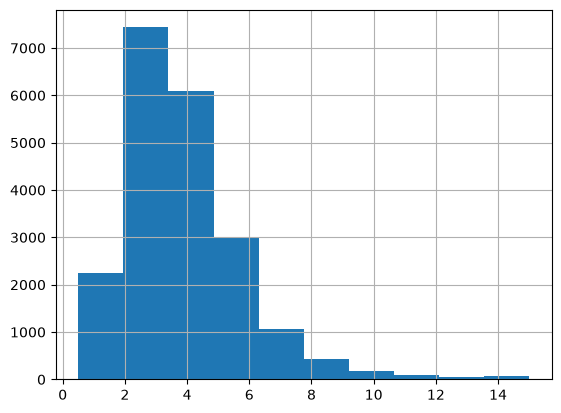

In [72]:
housing["median_income"].hist()

<Axes: >

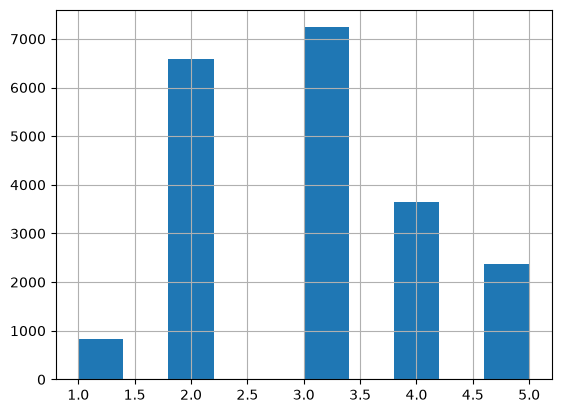

In [71]:
housing["income_cat"].hist()

# با استفاده از کتابخانه میگوییم از هر دسته 

In [78]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [84]:
from sklearn.model_selection import StratifiedShuffleSplit

In [85]:
split=StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=42)

In [86]:
split

StratifiedShuffleSplit(n_splits=10, random_state=42, test_size=0.2,
            train_size=None)

In [88]:
split.split(housing, housing["income_cat"])

<generator object BaseShuffleSplit.split at 0x000002D7F1DA6C40>

In [89]:
strat_train_set = housing.loc[train_index]
strat_test_set = housing.loc[test_index]

In [90]:
 strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13096,-122.42,37.80,52,3321,1115.0,1576,1034,2.0987,458300,NEAR BAY,2
14973,-118.38,34.14,40,1965,354.0,666,357,6.0876,483800,<1H OCEAN,5
3785,-121.98,38.36,33,1083,217.0,562,203,2.4330,101700,INLAND,2
14689,-117.11,33.75,17,4174,851.0,1845,780,2.2618,96100,INLAND,2
20507,-118.15,33.77,36,4366,1211.0,1912,1172,3.5292,361800,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41,2237,597.0,938,523,4.7105,500001,<1H OCEAN,4
13105,-119.31,36.32,23,2945,592.0,1419,532,2.5733,88800,INLAND,2
19301,-117.06,32.59,13,3920,775.0,2814,760,4.0616,148800,NEAR OCEAN,3
19121,-118.40,34.06,37,3781,873.0,1725,838,4.1455,500001,<1H OCEAN,3


In [91]:
 strat_test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
3905,-121.95,37.11,21,2387,357.0,913,341,7.7360,397700,<1H OCEAN,5
16821,-118.01,33.89,36,1589,265.0,804,272,4.6354,202900,<1H OCEAN,4
2900,-118.18,33.74,30,5915,1750.0,2136,1503,4.0968,310000,NEAR OCEAN,3
7193,-122.48,37.74,52,2166,423.0,1072,370,4.1310,314300,NEAR OCEAN,3
13928,-122.39,37.78,5,1405,515.0,725,392,3.6037,187500,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...,...
12369,-124.16,40.79,46,3042,597.0,1206,541,2.1135,90600,NEAR OCEAN,2
8707,-119.01,35.39,29,1820,459.0,1134,419,1.8289,59400,INLAND,2
16634,-123.01,38.67,33,914,147.0,394,132,4.6875,246200,<1H OCEAN,4
9779,-122.03,37.60,24,2077,383.0,1488,389,4.5721,214700,NEAR BAY,4


In [92]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

<Axes: xlabel='longitude', ylabel='latitude'>

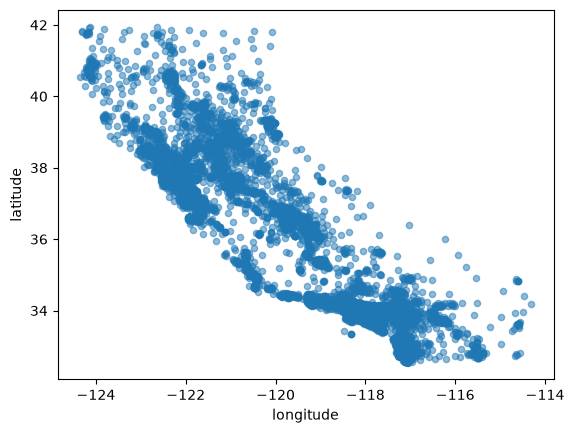

In [95]:
housing.plot(kind="scatter", x="longitude", y="latitude",alpha=.5)

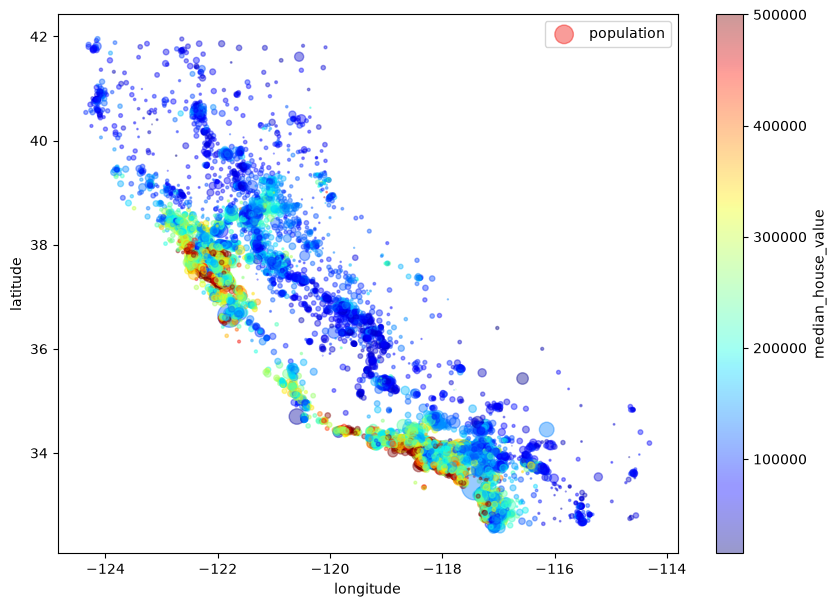

In [96]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing["population"]/100, label="population", figsize=(10,7),
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [ ]:
corr_matrix = housing.corr()
Now let’s look at how much each attribute correlates with the median house value:
>>> corr_matrix["median_house_value"].sort_values(ascending=False)

In [98]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,2
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,2
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND,2
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND,2


In [103]:
corr_matrix=housing.corr()

In [110]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...,...
20633,-121.53,39.19,27,2080,412.0,1082,382,2.5495,98300,INLAND,2
20634,-121.56,39.27,28,2332,395.0,1041,344,3.7125,116800,INLAND,3
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND,2
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND,2


In [113]:
housing = housing.iloc[:, :-2]

In [114]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [115]:
corr_matrix=housing.corr()

In [116]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [ ]:
 corr_matrix["median_house_value"].sort_values(ascending=False)

In [117]:
corr_matrix["median_house_value"]

longitude            -0.045967
latitude             -0.144160
housing_median_age    0.105623
total_rooms           0.134153
total_bedrooms        0.049686
population           -0.024650
households            0.065843
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [118]:
corr_matrix["median_house_value"].sort_values

<bound method Series.sort_values of longitude            -0.045967
latitude             -0.144160
housing_median_age    0.105623
total_rooms           0.134153
total_bedrooms        0.049686
population           -0.024650
households            0.065843
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64>